## Introducing the ideal synthetic SV modes

Unscaled, unresolved mode phasors truncated through spherical harmonic degree 15.

In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *

plt.rcParams.update({"font.size": 11})

In [41]:
# Select two modes and a time index
selected_modes = [1, 58]
demo_time = 20
nmax = 15

mode_numbers = np.arange(1, 63)
mode_summary = {}
mode_periods = []
mode_peak_degrees = []

for mode_number in mode_numbers:
    mode_data = Component_Load_SV(mode_number, nmax=nmax)
    phasor = mode_data["gnm"]
    eigenvalue = mode_data["eigenvalue"]
    period = 2 * np.pi / np.abs(eigenvalue.imag)
    lowes_spectrum = Instantaneous_Lowes_Spectrum(
        phasor, a=r_earth, r=r_cmb
    )
    peak_degree = np.argmax(lowes_spectrum) + 1

    mode_summary[mode_number] = {
        "phasor": phasor,
        "eigenvalue": eigenvalue,
        "period": period,
        "lowes_spectrum": lowes_spectrum,
        "peak_degree": peak_degree,
    }
    mode_periods.append(period)
    mode_peak_degrees.append(peak_degree)

mode_periods = np.asarray(mode_periods)
mode_peak_degrees = np.asarray(mode_peak_degrees)

plot_longitude = (longitude + 180) % 360 - 180
longitude_order = np.argsort(plot_longitude)
longitude_cyclic = np.append(plot_longitude[longitude_order], 180)

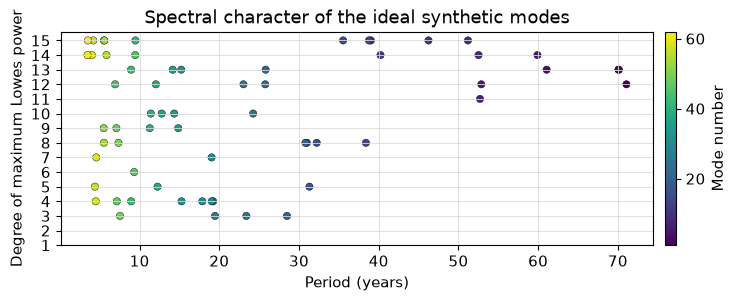

In [42]:
# Period and dominant Lowes degree of every ideal mode
fig, ax = plt.subplots(
    figsize=(text_width, 0.4 * text_width), constrained_layout=True
)
period_plot = ax.scatter(
    mode_periods, mode_peak_degrees, c=mode_numbers, cmap="viridis",
    s=28, edgecolor="black", linewidth=0.3,
)
ax.set(
    xlabel="Period (years)",
    ylabel="Degree of maximum Lowes power",
    yticks=np.arange(1, nmax + 1),
    title="Spectral character of the ideal synthetic modes",
)
ax.grid(True, color="0.85", linewidth=0.6)
fig.colorbar(period_plot, ax=ax, pad=0.02, label="Mode number")
plt.show()

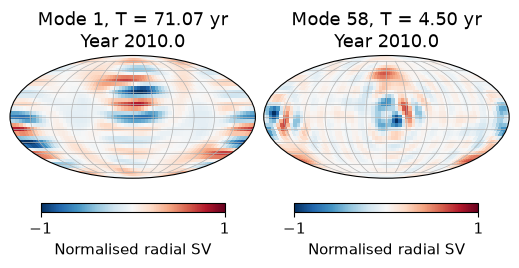

In [43]:
# Independently normalised fields for the selected modes at demo_time
selected_fields = []
for mode_number in selected_modes:
    mode_data = mode_summary[mode_number]
    gauss_step = np.real(
        np.exp(mode_data["eigenvalue"] * times_used_relative[demo_time])
        * mode_data["phasor"]
    )
    field = (A_15_r @ gauss_step).reshape(state_shape)
    selected_fields.append(field / np.max(np.abs(field)))

fig, axes = plt.subplots(
    1, 2, figsize=(0.7*text_width, 0.48 * text_width),
    subplot_kw={"projection": "mollweide"}, constrained_layout=True,
)
for ax, field, mode_number in zip(axes, selected_fields, selected_modes):
    field_sorted = field[:, longitude_order]
    field_cyclic = np.column_stack((field_sorted, field_sorted[:, 0]))
    map_plot = ax.pcolormesh(
        np.deg2rad(longitude_cyclic), np.deg2rad(latitude), field_cyclic,
        cmap="RdBu_r", vmin=-1, vmax=1, shading="auto",
    )
    ax.set_title(
        f"Mode {mode_number}, T = {mode_summary[mode_number]['period']:.2f} yr\n"
        f"Year {times_used[demo_time]:.1f}"
    )
    ax.grid(True, color="0.7", linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    cbar = fig.colorbar(
        map_plot, ax=ax, orientation="horizontal", pad=0.08, shrink=0.75,
        label="Normalised radial SV",
    )
    cbar.set_ticks([-1, 1])

plt.show()

In [44]:
# Real and imaginary radial SV phasor components
phasor_mode = selected_modes[1]
phasor_data = mode_summary[phasor_mode]
phasor_fields = np.asarray([
    (A_15_r @ np.real(phasor_data["phasor"])).reshape(state_shape),
    (A_15_r @ np.imag(phasor_data["phasor"])).reshape(state_shape),
])
phasor_fields /= np.max(np.abs(phasor_fields))

# Plotting is combined with the three time evaluations below

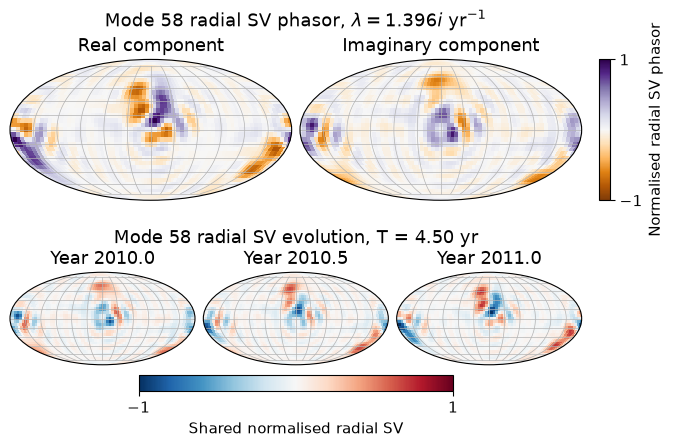

In [45]:
# Three consecutive evaluations of the first selected mode
time_indices = [demo_time, demo_time+1, demo_time+2]
time_fields = []
for time_index in time_indices:
    gauss_step = np.real(
        np.exp(phasor_data["eigenvalue"] * times_used_relative[time_index])
        * phasor_data["phasor"]
    )
    time_fields.append((A_15_r @ gauss_step).reshape(state_shape))

shared_limit = np.max(np.abs(time_fields))
time_fields = np.asarray(time_fields) / shared_limit

fig = plt.figure(
    figsize=(0.8*text_width, 0.6 * text_width), constrained_layout=True
)
phasor_subfigure, time_subfigure = fig.subfigures(2, 1)

phasor_axes = phasor_subfigure.subplots(
    1, 2, subplot_kw={"projection": "mollweide"}
)
for ax, field, component in zip(
    phasor_axes, phasor_fields, ["Real", "Imaginary"]
):
    field_sorted = field[:, longitude_order]
    field_cyclic = np.column_stack((field_sorted, field_sorted[:, 0]))
    phasor_plot = ax.pcolormesh(
        np.deg2rad(longitude_cyclic), np.deg2rad(latitude), field_cyclic,
        cmap="PuOr", vmin=-1, vmax=1, shading="auto",
    )
    ax.set_title(f"{component} component")
    ax.grid(True, color="0.7", linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

phasor_subfigure.suptitle(
    rf"Mode {phasor_mode} radial SV phasor, "
    rf"$\lambda={phasor_data['eigenvalue'].imag:.3f}i$ yr$^{{-1}}$"
)
phasor_cbar_axis = inset_axes(
    phasor_axes[-1], width="4%", height="100%", loc="lower left",
    bbox_to_anchor=(1.06, 0, 1, 1),
    bbox_transform=phasor_axes[-1].transAxes, borderpad=0,
)
phasor_cbar = phasor_subfigure.colorbar(
    phasor_plot, cax=phasor_cbar_axis, orientation="vertical",
    label="Normalised radial SV phasor",
)
phasor_cbar.set_ticks([-1, 1])

time_axes = time_subfigure.subplots(
    1, 3, subplot_kw={"projection": "mollweide"}
)
for ax, field, time_index in zip(time_axes, time_fields, time_indices):
    field_sorted = field[:, longitude_order]
    field_cyclic = np.column_stack((field_sorted, field_sorted[:, 0]))
    time_plot = ax.pcolormesh(
        np.deg2rad(longitude_cyclic), np.deg2rad(latitude), field_cyclic,
        cmap="RdBu_r", vmin=-1, vmax=1, shading="auto",
    )
    ax.set_title(f"Year {times_used[time_index]:.1f}")
    ax.grid(True, color="0.7", linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

time_subfigure.suptitle(
    f"Mode {phasor_mode} radial SV evolution, "
    f"T = {phasor_data['period']:.2f} yr"
)
time_cbar = time_subfigure.colorbar(
    time_plot, ax=time_axes, orientation="horizontal",
    pad=0.08, shrink=0.55, label="Shared normalised radial SV",
)
time_cbar.set_ticks([-1, 1])
plt.show()